# Atividade 02 — Diagnóstico, Baseline e EDA

**Script R equivalente:** [`../scriptsR/02-analise-exploratoria.R`](../scriptsR/02-analise-exploratoria.R)

**Explicação detalhada (consolidado):** [consolidado/02-analise-exploratoria.md](https://github.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/blob/main/consolidado/02-analise-exploratoria.md)

**Propósito deste notebook:** permitir a execução desta atividade no Google Colab (runtime R), exibindo todas as saídas e gráficos inline. Diferente do script `.R`, este notebook **não grava arquivos** — não salva `.png` nem relatórios `.md`.

**Alvo:** `mortalidade_60_69` (mortes por mil hab. na faixa 60–69).

**Como rodar no Colab:** `Runtime` → `Change runtime type` → selecionar **R** → `Run all`.


In [1]:
# =============================================================
# SETUP — Atividade 02
# =============================================================
# No Google Colab: Runtime > Change runtime type > R
# Esta atividade nao requer pacotes externos.

# Opcoes de exibicao de graficos inline (padrao do notebook)
options(repr.plot.width = 7, repr.plot.height = 7)

cat("[INFO] Setup concluido.\n")

[INFO] Setup concluido.


In [2]:
# =============================================================
# DADOS — Atividade 02
# =============================================================
arquivo_local <- file.path("..", "bancoDeDados", "df_ipdm_baixada_por_municipio.csv")
url_github    <- "https://raw.githubusercontent.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/main/estrutura/bancoDeDados/df_ipdm_baixada_por_municipio.csv"

if (file.exists(arquivo_local)) {
  origem_dados <- arquivo_local
  cat("[INFO] Carregando banco LOCAL.\n")
} else {
  origem_dados <- url_github
  cat("[INFO] Carregando do GitHub.\n")
}

dados_brutos <- read.csv(origem_dados, sep = ";", dec = ",", fileEncoding = "latin1",
                         check.names = FALSE, stringsAsFactors = FALSE)

dados <- data.frame(
  cod_ibge          = factor(dados_brutos[[1]]),
  municipio         = factor(dados_brutos[[2]]),
  ano               = as.integer(dados_brutos[[3]]),
  riqueza           = as.numeric(dados_brutos[[4]]),
  longevidade       = as.numeric(dados_brutos[[5]]),
  escolaridade      = as.numeric(dados_brutos[[6]]),
  ipdm              = as.numeric(dados_brutos[[7]]),
  mortalidade_60_69 = as.numeric(dados_brutos[[8]]),
  distorcao_em      = as.numeric(dados_brutos[[9]]),
  pib_per_capita    = as.numeric(dados_brutos[[10]])
)

# Alvo binario
mediana_mort <- median(dados$mortalidade_60_69)
dados$mortalidade_alta <- as.integer(dados$mortalidade_60_69 > mediana_mort)

n <- nrow(dados)
p <- 9  # preditores validos

cat("[INFO] Dados carregados:", n, "linhas.\n")

[INFO] Carregando banco LOCAL.
[INFO] Dados carregados: 54 linhas.


In [3]:
# =============================================================
# ANALISE — Atividade 02
# =============================================================
cat("================ PROTOCOLO DE DIAGNOSTICO ================\n")

# Passo 1 — correlacoes com o ALVO mortalidade_60_69
num_vars <- dados[sapply(dados, is.numeric)]
cor_y <- sort(abs(cor(num_vars, use = "complete.obs")[, "mortalidade_60_69"]), decreasing = TRUE)
cat("\n--- Passo 1: Correlacoes com mortalidade_60_69 ---\n")
print(round(cor_y, 4))
cat("Leitura: longevidade e ipdm aparecem como altamente correlacionados —\n")
cat("por isso sao EXCLUIDOS como preditores (circularidade conceitual).\n")
cat("Preditores validos: escolaridade, distorcao_em, pib_per_capita, riqueza.\n")

# Passo 2 — n vs p
cat("\n--- Passo 2: n vs p ---\n")
cat("n =", n, "| p_validos =", p, "| n/p =", round(n / p, 2), "\n")
cat("Diagnostico: n/p < 10 => parsimonia ou regularizacao.\n")

# Passo 3 — balanco
cat("\n--- Passo 3: Balanco (mortalidade_alta) ---\n")
tab_cls <- table(dados$mortalidade_alta)
print(tab_cls); print(prop.table(tab_cls))

# Passo 4 — NAs
cat("\n--- Passo 4: NAs ---\n")
print(colSums(is.na(dados)))

# Baselines
cat("\n================ BASELINES ================\n")
base_reg  <- sd(dados$mortalidade_60_69)
base_cls  <- max(table(dados$mortalidade_alta)) / n
cat("Baseline regressao (RMSE = sd(Y)):", round(base_reg, 4), "\n")
cat("Baseline classificacao:", round(base_cls * 100, 2), " %\n")
cat("Unidade de Y: mortes por mil habitantes na faixa 60-69.\n")

cat("\n================ RESUMO NUMERICO ================\n")
print(summary(dados[, sapply(dados, is.numeric)]))

================ PROTOCOLO DE DIAGNOSTICO ================

--- Passo 1: Correlacoes com mortalidade_60_69 ---
mortalidade_60_69  mortalidade_alta       longevidade              ipdm 
           1.0000            0.7649            0.4901            0.3977 
          riqueza    pib_per_capita      distorcao_em               ano 
           0.3933            0.2494            0.1277            0.0847 
     escolaridade 
           0.0340 
Leitura: longevidade e ipdm aparecem como altamente correlacionados —
por isso sao EXCLUIDOS como preditores (circularidade conceitual).
Preditores validos: escolaridade, distorcao_em, pib_per_capita, riqueza.

--- Passo 2: n vs p ---
n = 54 | p_validos = 9 | n/p = 6 
Diagnostico: n/p < 10 => parsimonia ou regularizacao.

--- Passo 3: Balanco (mortalidade_alta) ---

 0  1 
27 27 

  0   1 
0.5 0.5 

--- Passo 4: NAs ---
         cod_ibge         municipio               ano           riqueza 
                0                 0                 0         

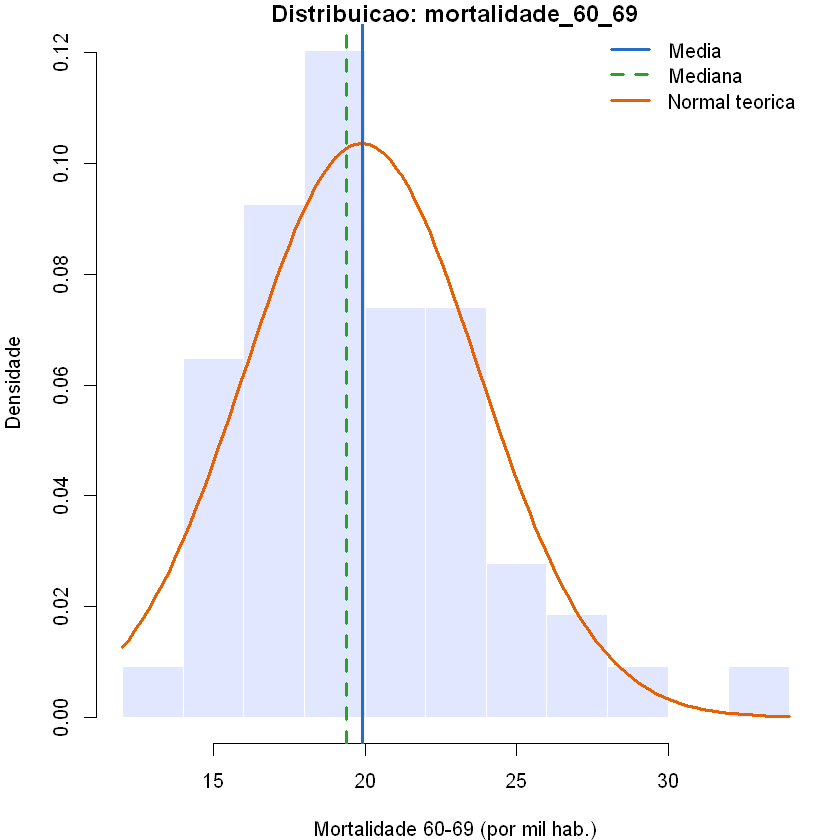

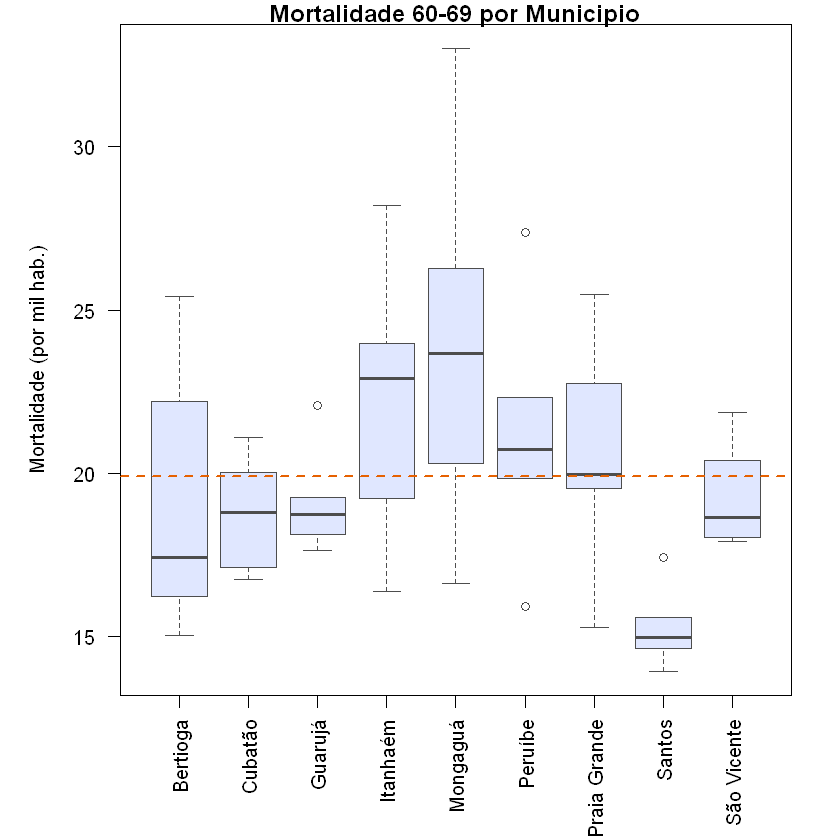

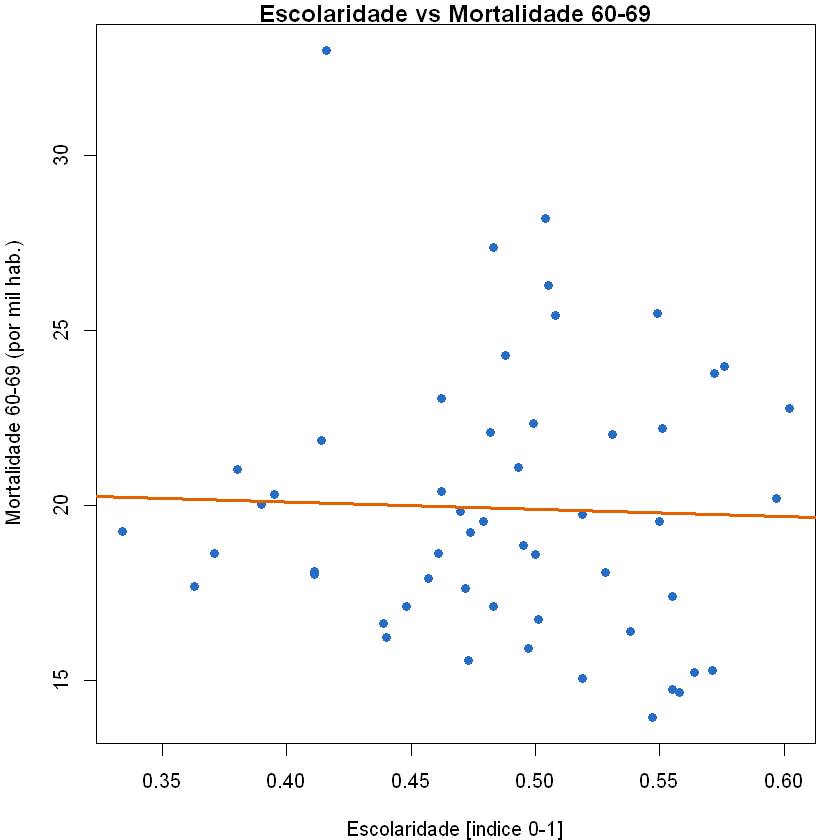

In [4]:
# =============================================================
# GRAFICOS — Atividade 02
# =============================================================
cazul <- "#276DC3"; claranja <- "#E66101"; cverde <- "#2CA02C"
croxo <- "#5E3C99"; cfill <- "#E0E7FF"

# Grafico 1 — histograma do alvo + Normal teorica
par(mar = c(4,4,1,1), pty = "s")
hist(dados$mortalidade_60_69, prob = TRUE, col = cfill, border = "white",
     xlab = "Mortalidade 60-69 (por mil hab.)", ylab = "Densidade",
     main = "Distribuicao: mortalidade_60_69")
curve(dnorm(x, mean(dados$mortalidade_60_69), sd(dados$mortalidade_60_69)),
      add = TRUE, lwd = 3, col = claranja)
abline(v = mean(dados$mortalidade_60_69),   col = cazul,  lwd = 3)
abline(v = median(dados$mortalidade_60_69), col = cverde, lwd = 3, lty = 2)
legend("topright", c("Media","Mediana","Normal teorica"),
       col = c(cazul,cverde,claranja), lwd = 3, lty = c(1,2,1), bty = "n")

# Grafico 2 — boxplot por municipio
par(mar = c(6,4,1,1), pty = "s")
boxplot(mortalidade_60_69 ~ municipio, data = dados, col = cfill, border = "gray30",
        main = "Mortalidade 60-69 por Municipio", xlab = "",
        ylab = "Mortalidade (por mil hab.)", las = 2)
abline(h = mean(dados$mortalidade_60_69), col = claranja, lwd = 2, lty = 2)

# Grafico 3 — dispersao escolaridade x mortalidade
par(mar = c(4,4,1,1), pty = "s")
plot(dados$escolaridade, dados$mortalidade_60_69, pch = 19, col = cazul,
     xlab = "Escolaridade [indice 0-1]", ylab = "Mortalidade 60-69 (por mil hab.)",
     main = "Escolaridade vs Mortalidade 60-69")
abline(lm(mortalidade_60_69 ~ escolaridade, data = dados), col = claranja, lwd = 3)